In [2]:
print('Hello World')

Hello World


In [3]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [4]:
GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")

In [5]:
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY is not set in the environment variables.")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

chat_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [7]:
chat_llm.invoke("Hello,How are you?").content

"Hello! I'm doing well, thank you for asking.\n\nHow are you today?"

In [8]:
from typing_extensions import TypedDict,Annotated
import operator
from langchain_core.messages import AnyMessage,HumanMessage,AIMessage

In [9]:
class GraphState(TypedDict):
    messages:Annotated[list[AnyMessage],operator.add]

In [10]:
{
    "messages": [HumanMessage(content="Hi, this is varshitha. Say hello in detail.")]
}


{'messages': [HumanMessage(content='Hi, this is varshitha. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [11]:
["hi"]

['hi']

In [12]:
["hi","how are you?"]

['hi', 'how are you?']

In [13]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [14]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [15]:
from langgraph.graph import StateGraph

In [16]:
builder = StateGraph(GraphState)

In [17]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [18]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [19]:
app = builder.compile()

In [20]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [21]:
from IPython.display import Image, display

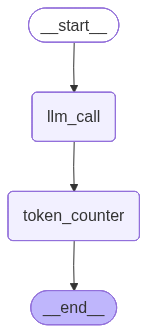

In [22]:
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is varshitha. Say hello in detail.")]
})

In [24]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is varshitha. Say hello in detail.
AIMessage : Well hello there, Varshitha!

It's an absolute pleasure to connect with you. I hope you're having a wonderful day so far!

I'm here and ready to assist you in any way I can. Please feel free to share whatever is on your mind, what you'd like to discuss, or what I can help you with. Don't hesitate to dive right in!
AIMessage : Total token number in the generated answer (word count) is 61


In [25]:
chat_llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x7e0167305340>, default_metadata=(), model_kwargs={})

In [26]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [27]:

api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [28]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [29]:
wiki_tool.run({"query":"Generative AI"})

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import requests

url = "https://en.wikipedia.org/w/api.php"

params = {
    "action": "query",
    "format": "json",
    "list": "search",
    "srsearch": "Generative AI"
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)
print("Headers:", response.headers.get("content-type"))
print("Response Text:")
print(response.text[:1000])

Status Code: 403
Headers: text/plain
Response Text:
Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also https://phabricator.wikimedia.org/T400119.



In [ ]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

/tmp/ipykernel_8406/2028030629.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [30]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

/tmp/ipykernel_8406/1068719361.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [31]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'The 2026 Job Market: Supporting Students and Closing the Skills Gap',
  'url': 'https://findingequilibriumfuturehighered.substack.com/p/the-2026-job-market-supporting-students',
  'content': '#### Some Final Thoughts\n\nA soft job market for graduates is nothing new for universities, but it certainly will be new for members of the Class of 2026. So, these students deserve our very best in helping them secure that first job. That said, every university should also be revisiting the way they think about and prepare their students for a successful career. It’s not only the right thing to do, in an environment where tuition revenue will become increasingly important, delivering career-ready graduates may well be the ticket to keeping the doors open…\n\n#### What’s Next? [...] That said, some are more pessimistic and a recent Wall Street Journal article called the current job market ‘fragile’, pointing out firms have plans to grow without hiring. Hopefully the NACE/_Economist_ t

In [32]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [33]:
search.invoke("what is the latest update on iphone17 release?")

"6 days ago ... It was succeeded by iOS 18 on September 16, 2024. iOS 17. Version of the iOS operating system. iOS 17 home screen on ... 1 Sept 2025 ... iPhone 17 could get a new style case and iPhone 17 Pro Cases have been revealed. iOS 18.7 is expected soon too. This is the weekly Apple News Update or the ... 14 Jan 2026 ... In this guide, we show you how to update iOS on your iPhone 17 or iPhone 17 Pro and install the latest software update on it. 3 Sept 2025 ... Date and time Tuesday, Sept. 9, 12 p.m. Pacific — to be confirmed. The last software release before the next iPhone OS is out will likely happen as soon as the ... 20 Sept 2025 ... this happen on my phone and my wife's on the new iphone 17 pro,. it's the stupid security update that apple release that cause this mess for new phone users."

In [34]:
from langchain_community.tools import YouTubeSearchTool

In [35]:
tool=YouTubeSearchTool()


In [36]:
tool.name

'youtube_search'

In [37]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [38]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=d2kxUVwWWwU&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [39]:
tool.run("sunny savita")

"['https://www.youtube.com/watch?v=ENzZuvahKwc&pp=ygUMc3Vubnkgc2F2aXRh', 'https://www.youtube.com/watch?v=Tf2ZzrCBJUI&pp=ygUMc3Vubnkgc2F2aXRh']"

In [40]:
def multiply(a:int,b:int) -> int:
    return a*b

In [41]:
multiply(10,20)

200

In [42]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [43]:
from langchain.tools import tool

In [44]:
@tool
def multiply(a:int,b:int) -> int:
    '''This tool is for multiplication'''
    return a*b

In [45]:
multiply.invoke({"a":10,"b":20})

200

In [46]:
multiply.name

'multiply'

In [47]:
multiply.description

'This tool is for multiplication'

In [48]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [50]:
@tool
def get_word_length(word:str) -> int:
    '''this is a tool to counter the length of the word'''
    return(len(word))

In [51]:
get_word_length.invoke("hello world")

11

In [52]:
get_word_length.invoke({"word": "hello world"})

11

In [ ]:
@tool
def call_gmail_api(args):
    '''this is a tool to call gmail api'''
    pass

In [53]:
import yfinance as yf

In [54]:
@tool
def get_stock_price(ticker:str) -> str:
    ''' this is a tool to get stock price using yfinance'''
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [55]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2198.90.'

In [56]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $310.89.'

In [57]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $396.92.'

In [58]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹747.05.'